In [21]:
import pandas as pd
import numpy as np
import rasterio
from rasterio.plot import show
from rasterio.windows import Window
import geopandas as gpd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import os
import warnings
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
import gc
import psutil
from tqdm import tqdm
warnings.filterwarnings('ignore')
from sklearn.model_selection import cross_val_score, StratifiedKFold

In [17]:
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['SimHei']   # 使用黑体
plt.rcParams['axes.unicode_minus'] = False     # 解决坐标轴负号显示问题

In [22]:
class Sentinel1IceClassifier:
    def __init__(self, selected_features=None):
        self.rf_model = None
        
        # 所有可用的特征选项
        self.available_features = {
            'HH': 'HH波段（水平发射-水平接收）',
            'HV': 'HV波段（水平发射-垂直接收）',
            'HH_div_HV': 'HH/HV比值',
            'HH_minus_HV': 'HH-HV差值', 
            'ANGLE': '入射角',
            'HH_norm': 'HH标准化',
            'HV_norm': 'HV标准化',
            'sum_div_diff': '总和除差值'
        }
        
        # 默认特征组合（如果没有指定）
        if selected_features is None:
            self.feature_names = ['HH', 'HV', 'HH_div_HV', 'ANGLE']
        else:
            self.feature_names = selected_features
        
        # 验证选择的特征是否有效
        for feature in self.feature_names:
            if feature not in self.available_features:
                raise ValueError(f"特征 '{feature}' 不在可用特征列表中")
            
        ###NOTE:tiff band name需要从tiff中读取 直接命名受限于波段计算顺序
        
        # TIFF波段名称
        self.tiff_band_names = ['HH', 'HV', 'ANGLE', 'SIC', 
                               'HH_mul_HV', 'HH_div_HV', 'sum_div_diff']
        
        self.class_names = ['ice', 'lead', 'refrozen']
        self.class_colors = ["#1f76b4", "#ff7f0e", "#2ca02c"]  # 蓝色、橙色、绿色
        
        print(f"初始化分类器，使用特征: {self.feature_names}")

    def update_selected_features(self, new_features):
        """更新选择的特征"""
        for feature in new_features:
            if feature not in self.available_features:
                raise ValueError(f"特征 '{feature}' 不在可用特征列表中")
        
        self.feature_names = new_features
        print(f"特征已更新为: {self.feature_names}")
        
        if self.rf_model is not None:
            print("警告: 特征已更改，需重新训练模型")
            self.rf_model = None

    def load_and_merge_samples(self, csv_files):
        """加载并合并多个日期的样本CSV文件"""
        print("正在加载样本数据...")
        all_samples = []
        
        if isinstance(csv_files, str):
            csv_files = [csv_files]
            
        for csv_file in csv_files:
            df = pd.read_csv(csv_file)
            print(f"加载文件: {csv_file}, 样本数: {len(df)}")
            all_samples.append(df)
        
        merged_samples = pd.concat(all_samples, ignore_index=True)
        print(f"合并后总样本数: {len(merged_samples)}")
        
        class_counts = merged_samples['class'].value_counts().sort_index()
        print("\n类别分布:")
        for class_id, count in class_counts.items():
            print(f"  {self.class_names[class_id-1]} (class {class_id}): {count} 样本")
        
        # --- 增加欠采样逻辑 ---
        min_count = class_counts.min()  # 找到样本数最少的类别数量
        balanced_samples = pd.DataFrame()

        print(f"\n进行欠采样，每个类别将保留 {min_count} 个样本...")
        for class_id in class_counts.index:
            class_samples = merged_samples[merged_samples['class'] == class_id]
            # 随机抽取与最少类别数量相等的样本
            sampled_class_samples = class_samples.sample(n=min_count, random_state=42) # 使用 random_state 保证可复现
            balanced_samples = pd.concat([balanced_samples, sampled_class_samples])
        
        # 再次检查新的类别分布
        balanced_class_counts = balanced_samples['class'].value_counts().sort_index()
        print("\n欠采样后类别分布:")
        for class_id, count in balanced_class_counts.items():
            print(f"  {self.class_names[class_id-1]} (class {class_id}): {count} 样本")
        
        print(f"欠采样后总样本数: {len(balanced_samples)}")
        
        return balanced_samples.sample(frac=1, random_state=42).reset_index(drop=True) # 随机打乱并重置索引

 
    def prepare_training_data(self, samples_df, filter_features=True):
        """
        准备训练数据，支持特征筛选
        """
        print("\n准备训练数据...")
        
        # 创建特征名称映射
        csv_feature_mapping = {
            'HH': 'HH',
            'HV': 'HV', 
            'HH_div_HV': 'HH_div_HV',
            'HH_minus_HV': 'HH_minus_HV',
            'indicenceAngle': 'ANGLE',  # 注意CSV中的拼写
            'HH_norm': 'HH_norm',
            'HV_norm': 'HV_norm',
            'sum_div_diff': 'sum_div_diff'
        }
        
        if filter_features:
            # 只选择当前配置使用的特征
            selected_csv_cols = []
            missing_features = []
            
            for feature in self.feature_names:
                csv_col = None
                for csv_name, std_name in csv_feature_mapping.items():
                    if std_name == feature:
                        csv_col = csv_name
                        break
                
                if csv_col and csv_col in samples_df.columns:
                    selected_csv_cols.append(csv_col)
                else:
                    missing_features.append(feature)
                    print(f"警告: CSV中未找到特征 '{feature}' 对应的列")
            
            if missing_features:
                print(f"缺失的特征: {missing_features}")
                self.feature_names = [f for f in self.feature_names if f not in missing_features]
        else:
            # 使用所有可用特征
            selected_csv_cols = [col for col in csv_feature_mapping.keys() if col in samples_df.columns]
        
        if not selected_csv_cols:
            raise ValueError("没有找到任何可用的特征列")
        
        X = samples_df[selected_csv_cols].copy()
        y = samples_df['class'].copy()
        
        # 重命名列以匹配标准特征名
        rename_mapping = {}
        for csv_col in selected_csv_cols:
            for csv_name, std_name in csv_feature_mapping.items():
                if csv_name == csv_col:
                    rename_mapping[csv_col] = std_name
                    break
        
        X.rename(columns=rename_mapping, inplace=True)
        
        if X.isnull().any().any():
            print("警告: 发现缺失值，将使用均值填充")
            X = X.fillna(X.mean())
            
        if filter_features:
            X = X[self.feature_names]
            
        print(f"实际使用的特征: {list(X.columns)}")
        print(f"特征矩阵形状: {X.shape}")
        print(f"目标变量形状: {y.shape}")
        
        return X, y
    def debug_feature_info(self):
            """调试函数：显示模型和分类器的特征信息"""
            print("=== 特征匹配调试信息 ===")
            print(f"分类器配置的特征: {self.feature_names}")
            print(f"特征数量: {len(self.feature_names)}")
            
            if self.rf_model is not None:
                print(f"模型期望的特征数: {getattr(self.rf_model, 'n_features_in_', '未知')}")
                if hasattr(self.rf_model, 'feature_names_in_'):
                    print(f"模型训练时的特征名: {self.rf_model.feature_names_in_}")
                
                # 检查是否匹配
                expected_features = getattr(self.rf_model, 'n_features_in_', len(self.feature_names))
                if len(self.feature_names) != expected_features:
                    print(f"❌ 特征数量不匹配！期望 {expected_features}，配置 {len(self.feature_names)}")
                else:
                    print("✅ 特征数量匹配")
            else:
                print("⚠️  模型尚未训练")
            
            print(f"可用特征列表: {list(self.available_features.keys())}")
            print("=" * 40)

    def check_tiff_bands(self, tiff_path):
        """检查TIFF文件的波段信息"""
        print(f"\n=== TIFF文件波段信息 ===")
        print(f"文件路径: {tiff_path}")
        
        with rasterio.open(tiff_path) as src:
            print(f"总波段数: {src.count}")
            print(f"影像尺寸: {src.height} x {src.width}")
            
            print("波段对应关系:")
            for i in range(min(src.count, len(self.tiff_band_names))):
                print(f"  波段 {i+1}: {self.tiff_band_names[i]}")
            
            # 检查所需特征是否可用
            print("\n特征可用性检查:")
            for feature in self.feature_names:
                if feature in self.tiff_band_names[:src.count]:
                    idx = self.tiff_band_names.index(feature)
                    print(f"  ✅ {feature}: 可用 (波段 {idx+1})")
                elif feature in ['HH_div_HV', 'HH_minus_HV', 'sum_div_diff']:
                    hh_available = 'HH' in self.tiff_band_names[:src.count]
                    hv_available = 'HV' in self.tiff_band_names[:src.count]
                    if hh_available and hv_available:
                        print(f"  ✅ {feature}: 可计算 (从HH和HV)")
                    else:
                        print(f"  ❌ {feature}: 无法计算 (缺少HH或HV)")
                else:
                    print(f"  ❌ {feature}: 不可用")
        
        print("=" * 40)

    def train_model(self, X, y, n_estimators=200):
        """训练随机森林模型"""
        print("\n训练随机森林模型...")
        
        self.rf_model = RandomForestClassifier(
            n_estimators=n_estimators,
            random_state=42,
            max_depth=None,
            min_samples_split=2,
            min_samples_leaf=1,
            n_jobs=-1
        )
        
        self.rf_model.fit(X, y)
        
        # 特征重要性
        feature_importance = pd.DataFrame({
            'feature': X.columns,
            'importance': self.rf_model.feature_importances_
        }).sort_values('importance', ascending=False)
        
        print("特征重要性:")
        for _, row in feature_importance.iterrows():
            print(f"  {row['feature']}: {row['importance']:.4f}")
        
        return self.rf_model

    def evaluate_model(self, X, y):
        """评估模型性能"""
        print("\n评估模型性能...")
        
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.3, random_state=42, stratify=y
        )
        
        y_pred = self.rf_model.predict(X_test)
        
        print("\n分类报告:")
        report = classification_report(y_test, y_pred, 
                                     target_names=self.class_names,
                                     output_dict=True)
        print(classification_report(y_test, y_pred, target_names=self.class_names))
        
        return report
    
    def evaluate_with_cv(self, X, y):
        """使用交叉验证评估模型"""
        print("\n使用5折交叉验证评估模型性能...")
        
        # 2. 创建一个分类器实例（注意：每次交叉验证都会重新训练）
        # 如果 self.rf_model 已经训练过，需要重新创建一个新的实例
        model_for_cv = self.rf_model 
        
        # 3. 定义交叉验证策略
        # 对于分类问题，强烈推荐使用 StratifiedKFold
        # shuffle=True 可以在分割前打乱数据，增加随机性
        cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
        
        # 4. 执行交叉验证
        # cross_val_score 会自动处理数据划分、模型训练和评估
        # 'scoring' 参数指定评估指标，例如 'accuracy', 'f1_macro', 'roc_auc' 等
        scores = cross_val_score(model_for_cv, X, y, cv=cv_strategy, scoring='accuracy')
        
        # 5. 打印结果
        print(f"每次验证的准确率: {scores}")
        print(f"平均准确率: {scores.mean():.4f}")
        print(f"准确率标准差: {scores.std():.4f}") # 标准差越小，模型性能越稳定
    
        return scores.mean(), scores.std()


    def calculate_chunk_size(self, tiff_path, target_memory_mb=1000):
        """
        根据影像尺寸和可用内存计算合适的chunk size
        """
        with rasterio.open(tiff_path) as src:
            height, width = src.height, src.width
            n_bands = src.count
            dtype = src.dtypes[0]
            
        # 计算每个像素的字节数
        dtype_bytes = np.dtype(dtype).itemsize
        
        # 计算整个影像的大小 (MB)
        total_size_mb = (height * width * n_bands * dtype_bytes) / (1024 * 1024)
        
        # 获取系统可用内存
        available_memory_mb = psutil.virtual_memory().available / (1024 * 1024)
        
        print(f"影像信息:")
        print(f"  尺寸: {height} x {width}")
        print(f"  波段数: {n_bands}")
        print(f"  数据类型: {dtype}")
        print(f"  影像大小: {total_size_mb:.1f} MB")
        print(f"  系统可用内存: {available_memory_mb:.1f} MB")
        
        # 设置目标内存使用量
        target_memory = min(target_memory_mb, available_memory_mb * 0.5)  # 不超过可用内存的50%
        
        # 计算chunk size
        if total_size_mb <= target_memory:
            # 如果影像较小，不需要分块
            chunk_size = min(height, width)
            print(f"影像较小，不需要分块处理")
        else:
            # 计算每个chunk的像素数
            pixels_per_chunk = (target_memory * 1024 * 1024) / (n_bands * dtype_bytes)
            chunk_size = int(np.sqrt(pixels_per_chunk))
            chunk_size = min(chunk_size, min(height, width))
            
        # 确保chunk_size至少为64
        chunk_size = max(64, chunk_size)
        
        print(f"建议的chunk size: {chunk_size}")
        print(f"预计内存使用: {(chunk_size**2 * n_bands * dtype_bytes) / (1024*1024):.1f} MB per chunk")
        
        return chunk_size

    def classify_with_chunks(self, tiff_path, output_path=None, chunk_size=None, target_memory_mb=1000):
        """
        分块处理大型影像进行分类
        """
        print(f"\n开始分块分类影像: {tiff_path}")
        
        # 自动计算chunk size
        if chunk_size is None:
            chunk_size = self.calculate_chunk_size(tiff_path, target_memory_mb)
        
        with rasterio.open(tiff_path) as src:
            profile = src.profile
            height, width = src.height, src.width
            
            print(f"影像尺寸: {height} x {width}")
            print(f"使用chunk size: {chunk_size}")
            
            # 准备输出数组
            classification_result = np.zeros((height, width), dtype=np.uint8)
            
            # 计算chunk数量
            n_chunks_y = (height + chunk_size - 1) // chunk_size
            n_chunks_x = (width + chunk_size - 1) // chunk_size
            total_chunks = n_chunks_y * n_chunks_x
            
            print(f"总共需要处理 {total_chunks} 个chunks ({n_chunks_y}x{n_chunks_x})")
            
            # 创建进度条
            with tqdm(total=total_chunks, desc="分类进度") as pbar:
                for i in range(n_chunks_y):
                    for j in range(n_chunks_x):
                        # 计算当前chunk的边界
                        row_start = i * chunk_size
                        row_end = min((i + 1) * chunk_size, height)
                        col_start = j * chunk_size
                        col_end = min((j + 1) * chunk_size, width)
                        
                        # 创建窗口
                        window = Window(col_start, row_start, 
                                      col_end - col_start, row_end - row_start)
                        
                        # 读取数据
                        chunk_data = src.read(window=window)
                        chunk_height, chunk_width = chunk_data.shape[1], chunk_data.shape[2]
                        
                        # 处理当前chunk
                        chunk_result = self._classify_chunk(chunk_data)
                        
                        # 将结果写入输出数组
                        classification_result[row_start:row_end, col_start:col_end] = chunk_result
                        
                        pbar.update(1)
                        
                        # 清理内存
                        del chunk_data, chunk_result
                        gc.collect()
        
        # 保存结果
        if output_path:
            self._save_classification_result(classification_result, profile, output_path)
        
        # 统计结果
        self._print_classification_stats(classification_result)
        
        return classification_result, profile

    def _classify_chunk(self, chunk_data):
        """对单个chunk进行分类"""
        n_bands, height, width = chunk_data.shape
        
        # 创建特征字典
        bands_dict = {}
        for i, band_name in enumerate(self.tiff_band_names):
            if i < n_bands:
                bands_dict[band_name] = chunk_data[i]
        
        # 准备特征数据
        feature_arrays = []
        available_features = []
        
        for feature_name in self.feature_names:
            if feature_name in bands_dict:
                feature_arrays.append(bands_dict[feature_name])
                available_features.append(feature_name)
            else:
                # 尝试计算衍生特征
                if feature_name == 'HH_div_HV' and 'HH' in bands_dict and 'HV' in bands_dict:
                    calculated_band = np.divide(bands_dict['HH'], bands_dict['HV'], 
                                              out=np.zeros_like(bands_dict['HH']), 
                                              where=bands_dict['HV']!=0)
                    feature_arrays.append(calculated_band)
                    available_features.append(feature_name)
                elif feature_name == 'HH_minus_HV' and 'HH' in bands_dict and 'HV' in bands_dict:
                    calculated_band = bands_dict['HH'] - bands_dict['HV']
                    feature_arrays.append(calculated_band)
                    available_features.append(feature_name)
        
        if not feature_arrays:
            return np.zeros((height, width), dtype=np.uint8)
        
        # 堆叠特征
        features = np.stack(feature_arrays, axis=0)
        features_2d = features.reshape(features.shape[0], -1).T
        
        # 创建有效像素掩膜
        if 'SIC' in bands_dict:
            sic_data = bands_dict['SIC']
            valid_mask = (sic_data > 0) & (sic_data <= 100)
        else:
            sample_band = feature_arrays[0]
            valid_mask = ~(np.isnan(sample_band) | np.isinf(sample_band) | (sample_band == 0))
        
        valid_pixels = valid_mask.flatten()
        
        # 处理无效值
        features_2d = np.nan_to_num(features_2d, nan=0, posinf=0, neginf=0)
        
        # 预测
        predictions_full = np.zeros(height * width, dtype=np.uint8)
        if np.sum(valid_pixels) > 0:
            valid_features = features_2d[valid_pixels]
            predictions_valid = self.rf_model.predict(valid_features)
            predictions_full[valid_pixels] = predictions_valid
        
        # 重塑为2D并设置无效区域为0
        chunk_result = predictions_full.reshape(height, width)
        chunk_result[~valid_mask] = 0
        
        return chunk_result

    def _save_classification_result(self, classification_result, profile, output_path):
        """保存分类结果"""
        output_profile = profile.copy()
        output_profile.update({
            'dtype': rasterio.uint8,
            'count': 1,
            'compress': 'lzw',
            'nodata': 0
        })
        
        with rasterio.open(output_path, 'w', **output_profile) as dst:
            dst.write(classification_result, 1)
        
        print(f"分类结果已保存到: {output_path}")

    def _print_classification_stats(self, classification_result):
        """打印分类统计信息"""
        unique, counts = np.unique(classification_result[classification_result > 0], 
                                 return_counts=True)
        print("\n分类结果统计:")
        total_classified = np.sum(counts) if len(counts) > 0 else 0
        
        for class_id, count in zip(unique, counts):
            if class_id > 0:
                class_name = self.class_names[class_id-1]
                percentage = count / total_classified * 100 if total_classified > 0 else 0
                print(f"  {class_name} (class {class_id}): {count:,} 像素 ({percentage:.2f}%)")

    def visualize_classification(self, classification_result, profile, 
                               original_tiff_path=None, save_path=None):
        """可视化分类结果"""
        print("\n生成分类结果可视化...")
        
        colors = ['black'] + self.class_colors  # 黑色用于无效区域
        cmap = ListedColormap(colors)
        
        if original_tiff_path:
            # 如果提供了原始影像，创建对比图
            fig, axes = plt.subplots(2, 2, figsize=(15, 12))
            
            with rasterio.open(original_tiff_path) as src:
                # 显示HH波段
                hh_data = src.read(1)  # 假设第一个波段是HH
                im1 = axes[0, 0].imshow(hh_data, cmap='gray')
                axes[0, 0].set_title('HH波段')
                axes[0, 0].axis('off')
                plt.colorbar(im1, ax=axes[0, 0], shrink=0.8)
                
                # 显示HV波段
                if src.count > 1:
                    hv_data = src.read(2)  # 假设第二个波段是HV
                    im2 = axes[0, 1].imshow(hv_data, cmap='gray')
                    axes[0, 1].set_title('HV波段')
                    axes[0, 1].axis('off')
                    plt.colorbar(im2, ax=axes[0, 1], shrink=0.8)
                
            # 显示分类结果
            im3 = axes[1, 0].imshow(classification_result, cmap=cmap, vmin=0, vmax=3)
            axes[1, 0].set_title('海冰分类结果')
            axes[1, 0].axis('off')
            
            # 创建图例
            legend_elements = [Patch(facecolor='black', label='无效区域')]
            for i, (class_name, color) in enumerate(zip(self.class_names, self.class_colors)):
                legend_elements.append(Patch(facecolor=color, label=f'{class_name} (类别 {i+1})'))
            
            axes[1, 0].legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(1, 1))
            
            # 统计图
            unique, counts = np.unique(classification_result[classification_result > 0], return_counts=True)
            if len(unique) > 0:
                class_labels = [self.class_names[int(cls)-1] for cls in unique]
                colors_for_bars = [self.class_colors[int(cls)-1] for cls in unique]
                
                bars = axes[1, 1].bar(class_labels, counts, color=colors_for_bars, alpha=0.7)
                axes[1, 1].set_title('分类结果统计')
                axes[1, 1].set_ylabel('像素数量')
                axes[1, 1].tick_params(axis='x', rotation=45)
                
                for bar, count in zip(bars, counts):
                    height = bar.get_height()
                    axes[1, 1].text(bar.get_x() + bar.get_width()/2., height,
                                   f'{count:,}', ha='center', va='bottom')
        else:
            # 只显示分类结果
            fig, axes = plt.subplots(1, 2, figsize=(15, 6))
            
            im = axes[0].imshow(classification_result, cmap=cmap, vmin=0, vmax=3)
            axes[0].set_title('海冰分类结果')
            axes[0].axis('off')
            
            legend_elements = [Patch(facecolor='black', label='无效区域')]
            for i, (class_name, color) in enumerate(zip(self.class_names, self.class_colors)):
                legend_elements.append(Patch(facecolor=color, label=f'{class_name} (类别 {i+1})'))
            
            axes[0].legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(1, 1))
            
            # 统计图
            unique, counts = np.unique(classification_result[classification_result > 0], return_counts=True)
            if len(unique) > 0:
                class_labels = [self.class_names[int(cls)-1] for cls in unique]
                colors_for_bars = [self.class_colors[int(cls)-1] for cls in unique]
                
                bars = axes[1].bar(class_labels, counts, color=colors_for_bars, alpha=0.7)
                axes[1].set_title('分类结果统计')
                axes[1].set_ylabel('像素数量')
                axes[1].tick_params(axis='x', rotation=45)
                
                for bar, count in zip(bars, counts):
                    height = bar.get_height()
                    axes[1].text(bar.get_x() + bar.get_width()/2., height,
                               f'{count:,}', ha='center', va='bottom')
        
        plt.tight_layout()
        
        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
            print(f"可视化结果已保存到: {save_path}")
        
        plt.show()


# test


In [44]:
# 2. 定义不同的特征组合用于测试
feature_combinations = {
    'basic': ['HH', 'HV', 'ANGLE'],
    'with_ratios': ['HH', 'HV', 'HH_div_HV', 'HH_minus_HV', 'ANGLE'],
    'normalized': ['HH_norm', 'HV_norm', 'ANGLE'],
    'comprehensive': ['HH', 'HV', 'HH_div_HV', 'ANGLE', 'sum_div_diff'],
    'minimal': ['HH', 'HV']  # 最小特征集
}


# 3. 选择特征组合 (用户可以修改这里)
selected_combination = 'comprehensive'  # 修改这里选择不同的特征组合
selected_features = feature_combinations[selected_combination]
print(f"\n3. 选择特征组合: {selected_combination}")
# custom_features = ['HH', 'HV', 'HH_div_HV', 'ANGLE']  # 自定义特征
# classifier = Sentinel1IceClassifier(selected_features=custom_features)


3. 选择特征组合: comprehensive


In [45]:
classifier = Sentinel1IceClassifier( selected_features)
csv_files = [
    r"J:\我的云端硬盘\Project_Yujie\RF Samples1\samplePoint_20230329T155110_20230329T155214_047861_05C03E_8378.csv",
    r"J:\我的云端硬盘\Project_Yujie\RF Samples1\samplePoint_20230412T153445_20230412T153549_048065_05C71E_CE44.csv",
    r"J:\我的云端硬盘\Project_Yujie\RF Samples1\samplePoint_20230426T151920_20230426T152020_048269_05CDF5_BEA4.csv",
    r"J:\我的云端硬盘\Project_Yujie\RF Samples1\samplePoint_20230429T122549_20230429T122643_048311_05CF66_60DE.csv",
    r"J:\我的云端硬盘\Project_Yujie\RF Samples1\samplePoint_20230703T123357_20230703T123501_049259_05EC59_E052.csv",
    r"J:\我的云端硬盘\Project_Yujie\RF Samples1\samplePoint_20230503T151005_20230503T151109_048371_05D160_BE0E (1).csv"
]   

samples = classifier.load_and_merge_samples(csv_files)

初始化分类器，使用特征: ['HH', 'HV', 'HH_div_HV', 'ANGLE', 'sum_div_diff']
正在加载样本数据...
加载文件: J:\我的云端硬盘\Project_Yujie\RF Samples1\samplePoint_20230329T155110_20230329T155214_047861_05C03E_8378.csv, 样本数: 4929
加载文件: J:\我的云端硬盘\Project_Yujie\RF Samples1\samplePoint_20230412T153445_20230412T153549_048065_05C71E_CE44.csv, 样本数: 210346
加载文件: J:\我的云端硬盘\Project_Yujie\RF Samples1\samplePoint_20230426T151920_20230426T152020_048269_05CDF5_BEA4.csv, 样本数: 86472
加载文件: J:\我的云端硬盘\Project_Yujie\RF Samples1\samplePoint_20230429T122549_20230429T122643_048311_05CF66_60DE.csv, 样本数: 36438
加载文件: J:\我的云端硬盘\Project_Yujie\RF Samples1\samplePoint_20230703T123357_20230703T123501_049259_05EC59_E052.csv, 样本数: 147876
加载文件: J:\我的云端硬盘\Project_Yujie\RF Samples1\samplePoint_20230503T151005_20230503T151109_048371_05D160_BE0E (1).csv, 样本数: 211858
合并后总样本数: 697919

类别分布:
  ice (class 1): 306848 样本
  lead (class 2): 258433 样本
  refrozen (class 3): 132638 样本


In [46]:
X, y = classifier.prepare_training_data(samples, filter_features=True)


准备训练数据...
实际使用的特征: ['HH', 'HV', 'HH_div_HV', 'ANGLE', 'sum_div_diff']
特征矩阵形状: (697919, 5)
目标变量形状: (697919,)


In [47]:
# 4. 训练模型
model = classifier.train_model(X, y, n_estimators=200)
evaluation = classifier.evaluate_model(X, y)


训练随机森林模型...
特征重要性:
  HH: 0.3078
  HV: 0.2522
  ANGLE: 0.2393
  HH_div_HV: 0.1246
  sum_div_diff: 0.0761

评估模型性能...

分类报告:
              precision    recall  f1-score   support

         ice       1.00      1.00      1.00     92055
        lead       1.00      1.00      1.00     77530
    refrozen       1.00      1.00      1.00     39791

    accuracy                           1.00    209376
   macro avg       1.00      1.00      1.00    209376
weighted avg       1.00      1.00      1.00    209376



In [ ]:
import os
output_dir = r"F:\NWP\Classification Result" 
# 8. 对masked Sentinel-1影像进行分类
# tiff_path = r"F:\NWP\S1_processed_for_classification\S1A_EW_GRDM_1SDH_20230412T121730_20230412T121835_048063_05C70C_40A9_EW_HH_HV_angle_int16x100_87caa6ee_1_processed.tif"
tiff_path = r"F:\NWP\S1_processed_for_classification\S1A_EW_GRDM_1SDH_20230502T142856_20230502T143000_048356_05D0E0_AAA7_EW_HH_HV_angle_int16x100_297ad0df_1_processed.tif"
visualization_path = os.path.join(output_dir, f"classification_visualization_{selected_combination}.png")
output_path = os.path.join(output_dir, f"classification_result_{selected_combination}.tif")

In [53]:
# 检查模型和特征配置
classifier.debug_feature_info()

# 检查TIFF文件波段信息
classifier.check_tiff_bands(tiff_path)

=== 特征匹配调试信息 ===
分类器配置的特征: ['HH', 'HV', 'HH_div_HV', 'ANGLE', 'sum_div_diff']
特征数量: 5
模型期望的特征数: 5
模型训练时的特征名: ['HH' 'HV' 'HH_div_HV' 'ANGLE' 'sum_div_diff']
✅ 特征数量匹配
可用特征列表: ['HH', 'HV', 'HH_div_HV', 'HH_minus_HV', 'ANGLE', 'HH_norm', 'HV_norm', 'sum_div_diff']

=== TIFF文件波段信息 ===
文件路径: F:\NWP\S1_processed_for_classification\S1A_EW_GRDM_1SDH_20230502T142856_20230502T143000_048356_05D0E0_AAA7_EW_HH_HV_angle_int16x100_297ad0df_1_processed.tif
总波段数: 7
影像尺寸: 13700 x 13838
波段对应关系:
  波段 1: HH
  波段 2: HV
  波段 3: ANGLE
  波段 4: SIC
  波段 5: HH_mul_HV
  波段 6: HH_div_HV
  波段 7: sum_div_diff

特征可用性检查:
  ✅ HH: 可用 (波段 1)
  ✅ HV: 可用 (波段 2)
  ✅ HH_div_HV: 可用 (波段 6)
  ✅ ANGLE: 可用 (波段 3)
  ✅ sum_div_diff: 可用 (波段 7)


In [54]:
classification_result, profile = classifier.classify_with_chunks(
    tiff_path=tiff_path,
    output_path=output_path,
    target_memory_mb=1500  # 目标内存使用量
)


开始分块分类影像: F:\NWP\S1_processed_for_classification\S1A_EW_GRDM_1SDH_20230502T142856_20230502T143000_048356_05D0E0_AAA7_EW_HH_HV_angle_int16x100_297ad0df_1_processed.tif
影像信息:
  尺寸: 13700 x 13838
  波段数: 7
  数据类型: float32
  影像大小: 5062.3 MB
  系统可用内存: 39357.1 MB
建议的chunk size: 7494
预计内存使用: 1499.6 MB per chunk
影像尺寸: 13700 x 13838
使用chunk size: 7494
总共需要处理 4 个chunks (2x2)


分类进度:   0%|          | 0/4 [00:09<?, ?it/s]


MemoryError: Unable to allocate 1.24 GiB for an array with shape (55325783, 1, 3) and data type float64


生成分类结果可视化...
可视化结果已保存到: F:\NWP\Classification Result\classification_visualization_comprehensive.png


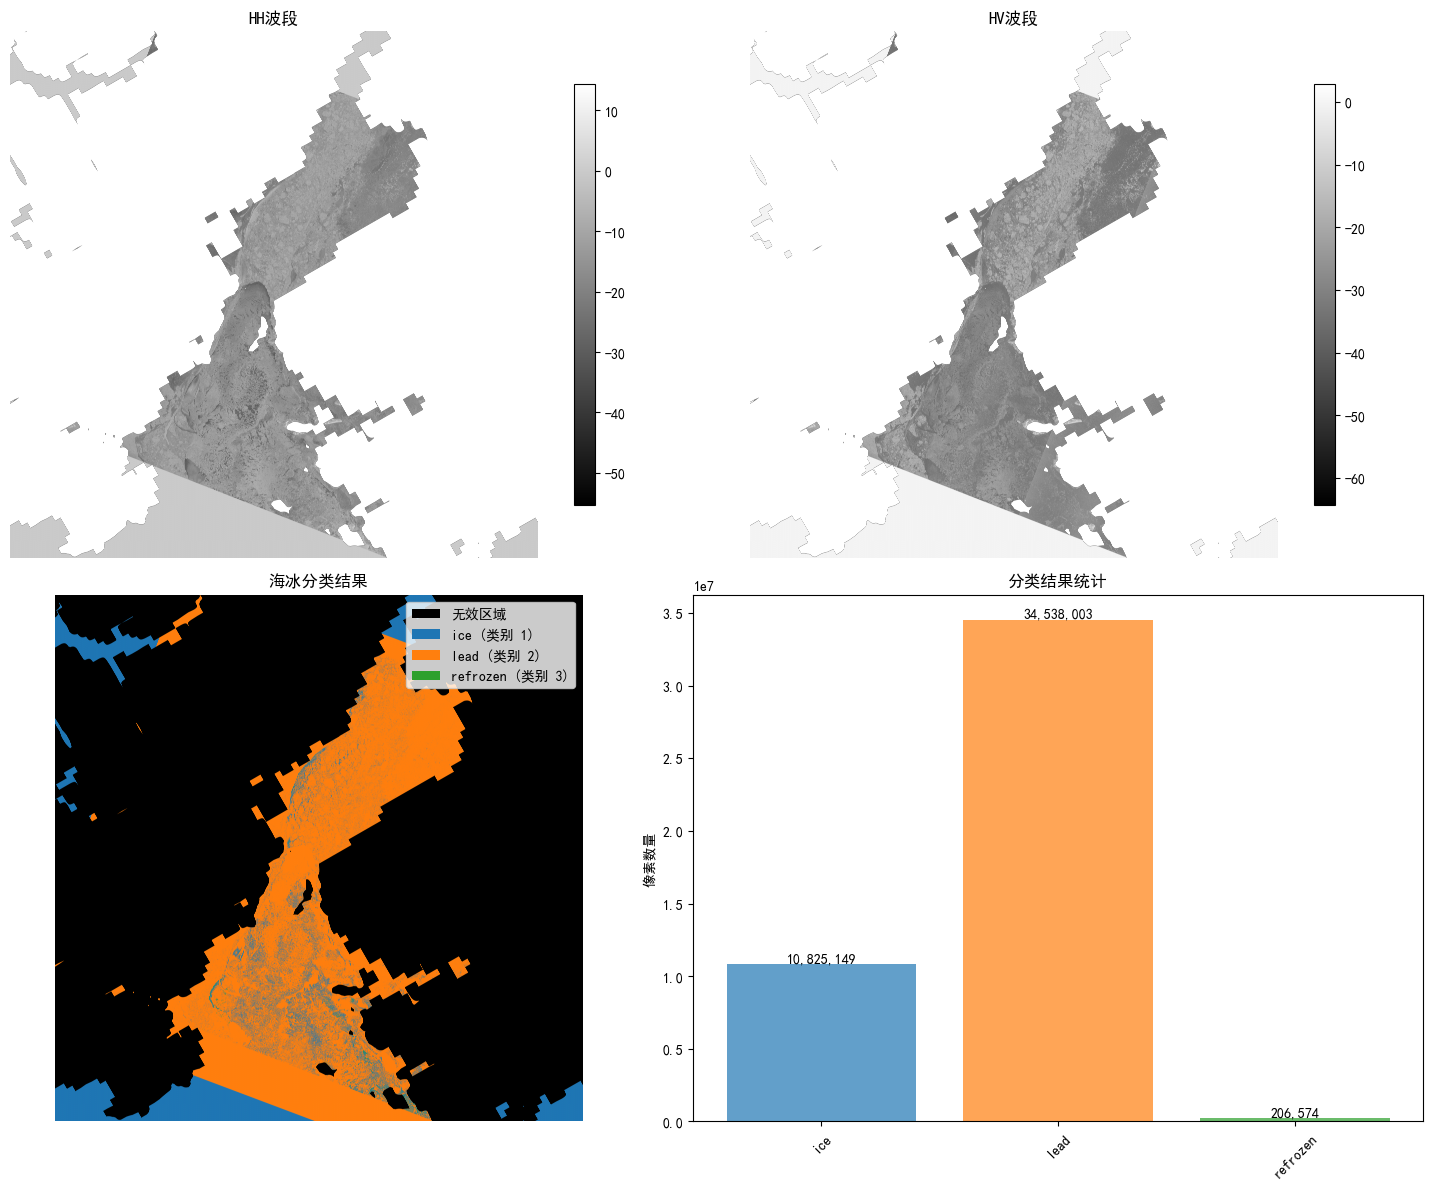

In [51]:
    # 6. 可视化结果
classifier.visualize_classification(
    classification_result, profile,
    original_tiff_path=tiff_path,
    save_path=visualization_path
)

# 1

In [23]:
def run_classification_workflow():
    # 2. 定义不同的特征组合用于测试
    feature_combinations = {
        'basic': ['HH', 'HV', 'ANGLE'],
        'with_ratios': ['HH', 'HV', 'HH_div_HV', 'HH_minus_HV', 'ANGLE'],
        'normalized': ['HH_norm', 'HV_norm', 'ANGLE'],
        'comprehensive': ['HH', 'HV', 'HH_div_HV', 'ANGLE', 'sum_div_diff'],
        'minimal': ['HH', 'HV']  # 最小特征集
    }


    # # 3. 选择特征组合 (用户可以修改这里)
    # selected_combination = 'basic'  # 修改这里选择不同的特征组合
    # selected_features = feature_combinations[selected_combination]
    custom_features = ['HH', 'HV','HH_div_HV', 'sum_div_diff']
    # custom_features = ['HH', 'HV', 'HH_div_HV', 'ANGLE']  # 自定义特征
    # classifier = Sentinel1IceClassifier(selected_features=custom_features)
    classifier = Sentinel1IceClassifier( selected_features = custom_features)
    csv_files = [
        r"J:\我的云端硬盘\Project_Yujie\RF Samples1\samplePoint_20230329T155110_20230329T155214_047861_05C03E_8378.csv",
        r"J:\我的云端硬盘\Project_Yujie\RF Samples1\samplePoint_20230412T153445_20230412T153549_048065_05C71E_CE44.csv",
        r"J:\我的云端硬盘\Project_Yujie\RF Samples1\samplePoint_20230426T151920_20230426T152020_048269_05CDF5_BEA4.csv",
        r"J:\我的云端硬盘\Project_Yujie\RF Samples1\samplePoint_20230429T122549_20230429T122643_048311_05CF66_60DE.csv",
        r"J:\我的云端硬盘\Project_Yujie\RF Samples1\samplePoint_20230703T123357_20230703T123501_049259_05EC59_E052.csv",
        r"J:\我的云端硬盘\Project_Yujie\RF Samples1\samplePoint_20230503T151005_20230503T151109_048371_05D160_BE0E (1).csv"
    ]   

    samples = classifier.load_and_merge_samples(csv_files)
    X, y = classifier.prepare_training_data(samples, filter_features=True)
        # 4. 训练模型
    model = classifier.train_model(X, y, n_estimators=200)
    
    evaluation = classifier.evaluate_model(X, y)
    evaluation_cv = classifier.evaluate_with_cv(X, y)
    
    import os
    output_dir = r"F:\NWP\Classification Result" 
    # 8. 对masked Sentinel-1影像进行分类
    tiff_path = r"F:\NWP\S1_processed_for_classification\S1A_EW_GRDM_1SDH_20230412T121730_20230412T121835_048063_05C70C_40A9_EW_HH_HV_angle_int16x100_87caa6ee_1_processed.tif"
    # tiff_path = r"F:\NWP\S1_processed_for_classification\S1A_EW_GRDM_1SDH_20230502T142856_20230502T143000_048356_05D0E0_AAA7_EW_HH_HV_angle_int16x100_297ad0df_1_processed.tif"
    visualization_path = os.path.join(output_dir, f"classification_visualization.png")
    output_path = os.path.join(output_dir, f"classification_result.tif")
        # 检查模型和特征配置
    classifier.debug_feature_info()

    # 检查TIFF文件波段信息
    classifier.check_tiff_bands(tiff_path)
    
    classification_result, profile = classifier.classify_with_chunks(
        tiff_path=tiff_path,
        output_path=output_path,
        target_memory_mb=1500  # 目标内存使用量
    )
        # 6. 可视化结果
    classifier.visualize_classification(
        classification_result, profile,
        original_tiff_path=tiff_path,
        save_path=visualization_path
    )
    print("分类工作流程完成！")
    

初始化分类器，使用特征: ['HH', 'HV', 'HH_div_HV', 'sum_div_diff']
正在加载样本数据...
加载文件: J:\我的云端硬盘\Project_Yujie\RF Samples1\samplePoint_20230329T155110_20230329T155214_047861_05C03E_8378.csv, 样本数: 4929
加载文件: J:\我的云端硬盘\Project_Yujie\RF Samples1\samplePoint_20230412T153445_20230412T153549_048065_05C71E_CE44.csv, 样本数: 210346
加载文件: J:\我的云端硬盘\Project_Yujie\RF Samples1\samplePoint_20230426T151920_20230426T152020_048269_05CDF5_BEA4.csv, 样本数: 86472
加载文件: J:\我的云端硬盘\Project_Yujie\RF Samples1\samplePoint_20230429T122549_20230429T122643_048311_05CF66_60DE.csv, 样本数: 36438
加载文件: J:\我的云端硬盘\Project_Yujie\RF Samples1\samplePoint_20230703T123357_20230703T123501_049259_05EC59_E052.csv, 样本数: 147876
加载文件: J:\我的云端硬盘\Project_Yujie\RF Samples1\samplePoint_20230503T151005_20230503T151109_048371_05D160_BE0E (1).csv, 样本数: 211858
合并后总样本数: 697919

类别分布:
  ice (class 1): 306848 样本
  lead (class 2): 258433 样本
  refrozen (class 3): 132638 样本

进行欠采样，每个类别将保留 132638 个样本...

欠采样后类别分布:
  ice (class 1): 132638 样本
  lead (class 2): 132638

分类进度: 100%|██████████| 4/4 [01:51<00:00, 27.88s/it]


分类结果已保存到: F:\NWP\Classification Result\classification_result.tif

分类结果统计:
  ice (class 1): 27,327,582 像素 (59.97%)
  lead (class 2): 4,820,837 像素 (10.58%)
  refrozen (class 3): 13,421,307 像素 (29.45%)

生成分类结果可视化...
可视化结果已保存到: F:\NWP\Classification Result\classification_visualization.png


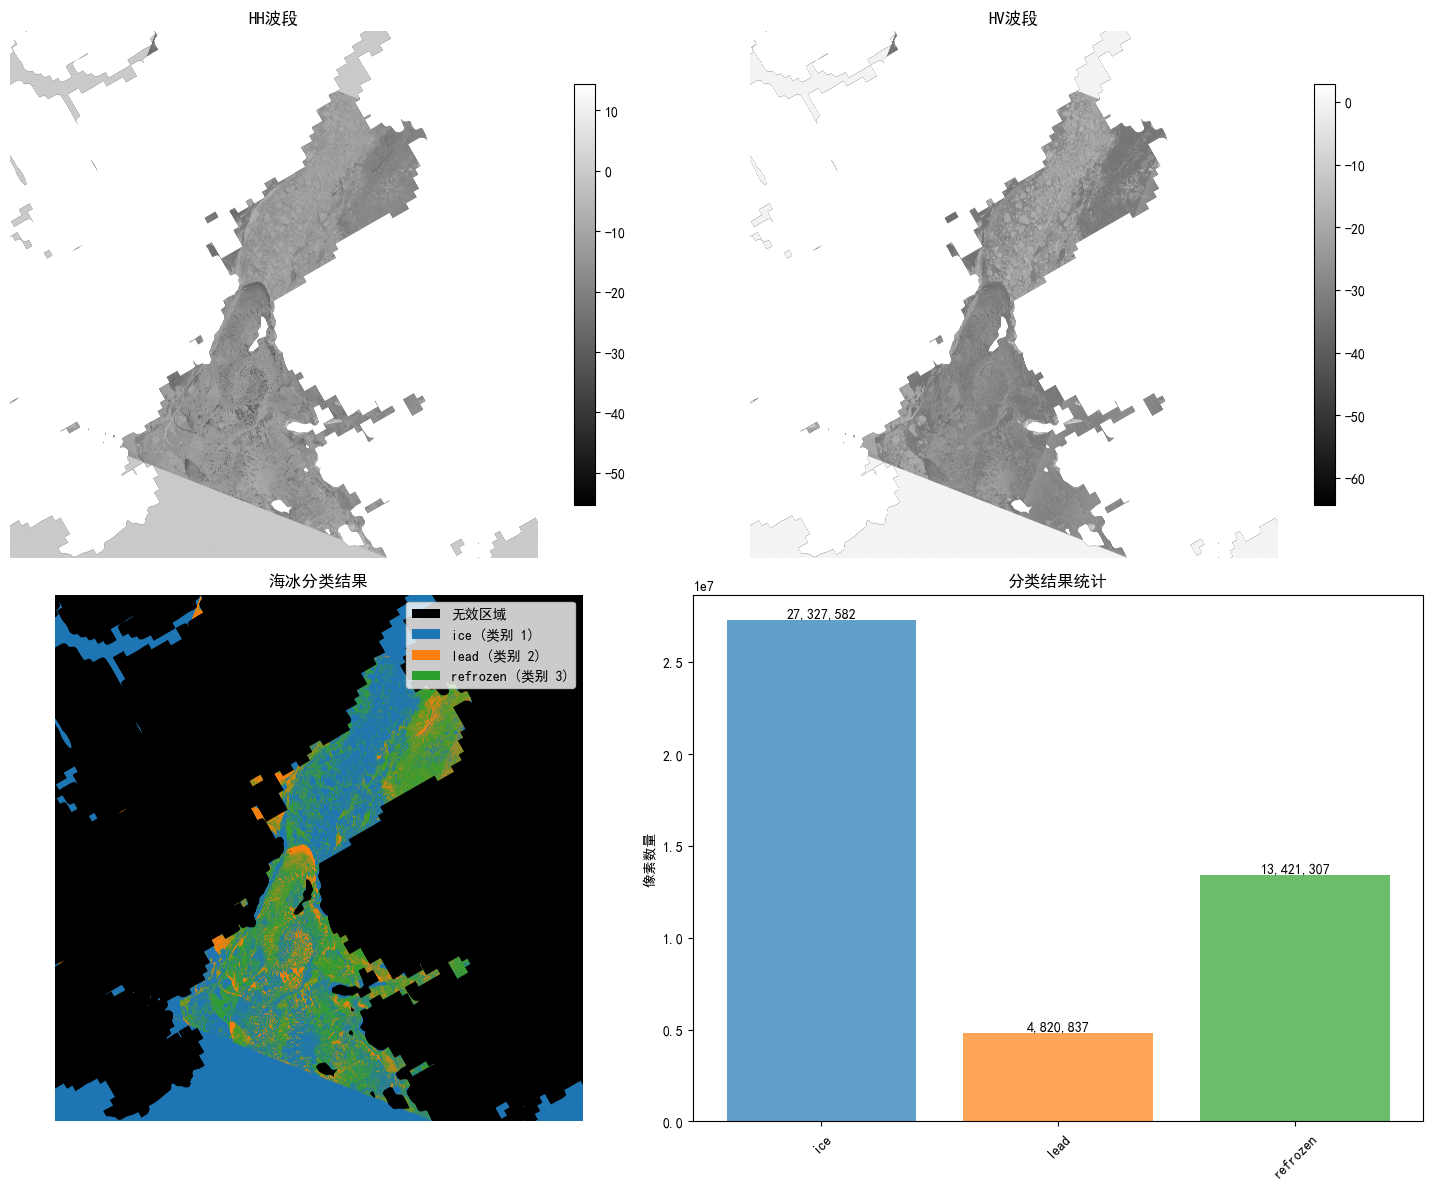

分类工作流程完成！


In [24]:
run_classification_workflow()
